In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/PalomaDuarte07/ecdv-energias-renovaveis/refs/heads/main/Dados/owid-energy-data.csv"
#link direto para o CSV no GitHub

df = pd.read_csv(url)

print(df.shape)
print(df.columns.tolist())

(23232, 130)
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh

tem bastante dado, agora vamos filtrar só o Brasil e as colunas que interessam pra gente.
Para contar a história da expansão das renováveis no Brasil, as colunas mais relevantes são: year, solar_electricity, wind_electricity, hydro_electricity, fossil_electricity, renewables_share_elec.

In [2]:
#filtra apenas os dados do Brasil
brasil = df[df['country'] == 'Brazil']

colunas = ['year', 'solar_electricity', 'wind_electricity',
           'hydro_electricity', 'fossil_electricity', 'renewables_share_elec']

brasil = brasil[colunas]

#remover as linhas onde todas as colunas de energia são vazias
brasil = brasil.dropna(subset=['solar_electricity', 'wind_electricity',
                                'hydro_electricity', 'fossil_electricity'], how='all')

print(brasil.head(10))
print(brasil.shape)

      year  solar_electricity  wind_electricity  hydro_electricity  \
3036  1965                0.0               0.0          25.514999   
3037  1966                0.0               0.0          27.906000   
3038  1967                0.0               0.0          29.188999   
3039  1968                0.0               0.0          30.549999   
3040  1969                0.0               0.0          32.692001   
3041  1970                0.0               0.0          39.800999   
3042  1971                0.0               0.0          43.199001   
3043  1972                0.0               0.0          50.681000   
3044  1973                0.0               0.0          57.889999   
3045  1974                0.0               0.0          65.679001   

      fossil_electricity  renewables_share_elec  
3036                 NaN                    NaN  
3037                 NaN                    NaN  
3038                 NaN                    NaN  
3039                 NaN     

Alguns pontos a notar:

fossil_electricity e renewables_share_elec estão como NaN nos anos mais antigos o que é normal, esses dados só existem a partir de certo ano
Solar e eólica zeradas nos anos 60/70 o que faz todo sentido historicamente.

In [4]:
#mostra as últimas 10 linhas (anos mais recentes)
print(brasil.tail(10))

#mostra um resumo: quantos valores válidos (não-NaN) tem em cada coluna
print(brasil.count())

      year  solar_electricity  wind_electricity  hydro_electricity  \
3086  2015           0.060000         21.629999         359.739990   
3087  2016           0.090000         33.490002         380.910004   
3088  2017           0.830000         42.369999         370.910004   
3089  2018           3.460000         48.480000         388.970001   
3090  2019           6.650000         55.990002         397.880005   
3091  2020          10.750000         57.049999         396.380005   
3092  2021          16.750000         72.290001         362.820007   
3093  2022          30.129999         81.629997         427.109985   
3094  2023          50.630001         95.800003         426.000000   
3095  2024          71.320000        108.489998         413.209991   

      fossil_electricity  renewables_share_elec  
3086          135.179993              74.207703  
3087           97.209999              80.467789  
3088          106.559998              79.247269  
3089           90.430000     

Solar saiu de 0.06 TWh em 2015 para 71 TWh em 2024

Eólica mais que quintuplicou de 2015 a 2024

Fósseis caíram de 135 para 78 TWh

88% da eletricidade do Brasil veio de renováveis em 2023

Temos dados completos a partir de 1985, bom.

In [5]:
#filtra apenas os anos a partir de 1985
brasil = brasil[brasil['year'] >= 1985]

#reseta o índice da tabela para ficar organizado
brasil = brasil.reset_index(drop=True)

print(f"Período: {brasil['year'].min()} a {brasil['year'].max()}")
print(f"Total de anos: {len(brasil)}")
print(brasil.head())

Período: 1985 a 2024
Total de anos: 40
   year  solar_electricity  wind_electricity  hydro_electricity  \
0  1985                0.0               0.0         178.375000   
1  1986                0.0               0.0         182.419006   
2  1987                0.0               0.0         185.600006   
3  1988                0.0               0.0         199.093002   
4  1989                0.0               0.0         204.690002   

   fossil_electricity  renewables_share_elec  
0            8.859108              93.680313  
1           16.371967              91.828995  
2           13.192775              93.033165  
3           11.912065              94.175438  
4           11.815858              93.845985  


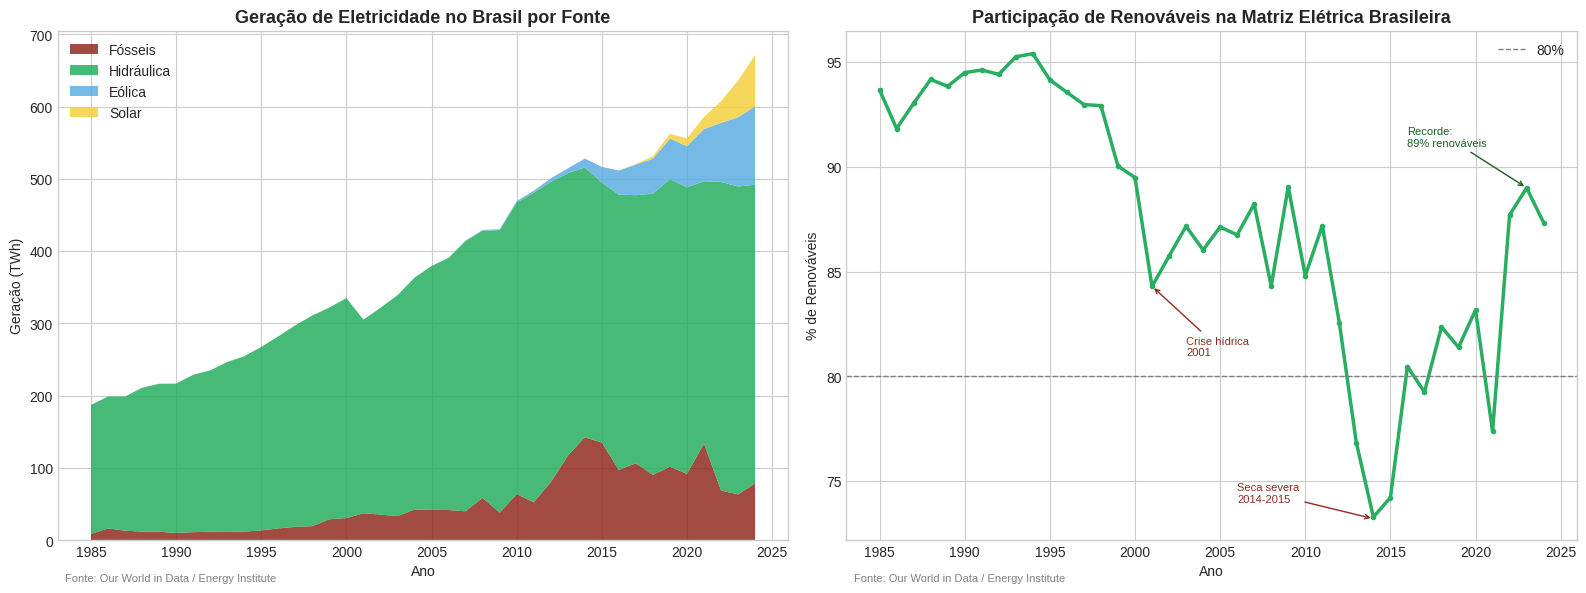

In [7]:
#agora começamos as visualizações
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#gráfico1: Área empilhada por fonte
#fósseis ficam por baixo para aparecerem "em cima" no gráfico empilhado, do outro jeito ficou esquisito
ax1.stackplot(brasil['year'],
              brasil['fossil_electricity'],
              brasil['hydro_electricity'],
              brasil['wind_electricity'],
              brasil['solar_electricity'],
              labels=['Fósseis', 'Hidráulica', 'Eólica', 'Solar'],
              colors=['#922b21', '#27ae60', '#5dade2', '#f4d03f'],
              alpha=0.85)

ax1.set_title('Geração de Eletricidade no Brasil por Fonte', fontsize=13, fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Geração (TWh)')
ax1.legend(loc='upper left')

#crédito da fonte no rodapé do gráfico 1
ax1.annotate('Fonte: Our World in Data / Energy Institute',
             xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='gray')

#gráfico2: % de renováveis com anotações
ax2.plot(brasil['year'], brasil['renewables_share_elec'],
         color='#27ae60', linewidth=2.5, marker='o', markersize=3)

# linha de referência em 80%
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80%')

#anotações explicando quedas importantes
ax2.annotate('Crise hídrica\n2001',
             xy=(2001, 84.3), xytext=(2003, 81),
             fontsize=8, color='#922b21',
             arrowprops=dict(arrowstyle='->', color='#922b21'))

ax2.annotate('Seca severa\n2014-2015',
             xy=(2014, 73.2), xytext=(2006, 74),
             fontsize=8, color='#922b21',
             arrowprops=dict(arrowstyle='->', color='#922b21'))

ax2.annotate('Recorde:\n89% renováveis',
             xy=(2023, 89.0), xytext=(2016, 91),
             fontsize=8, color='#1a5e20',
             arrowprops=dict(arrowstyle='->', color='#1a5e20'))

ax2.set_title('Participação de Renováveis na Matriz Elétrica Brasileira', fontsize=13, fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('% de Renováveis')
ax2.legend()

#crédito da fonte no rodapé do gráfico 2
ax2.annotate('Fonte: Our World in Data / Energy Institute',
             xy=(0.01, -0.08), xycoords='axes fraction', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('visualizacao.png', dpi=150, bbox_inches='tight')
plt.show()